In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## TASK 1

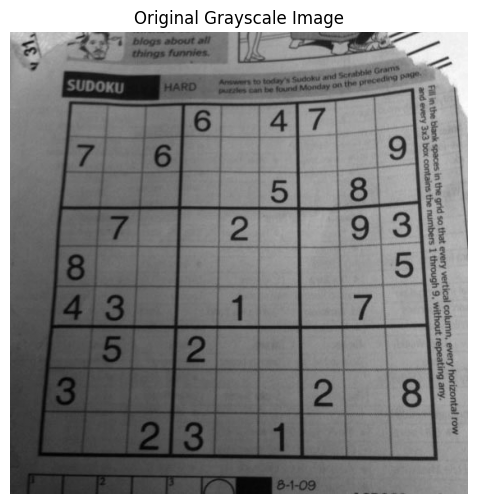

In [2]:
img = cv2.imread("input/sudoku.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found")

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

Global threshold

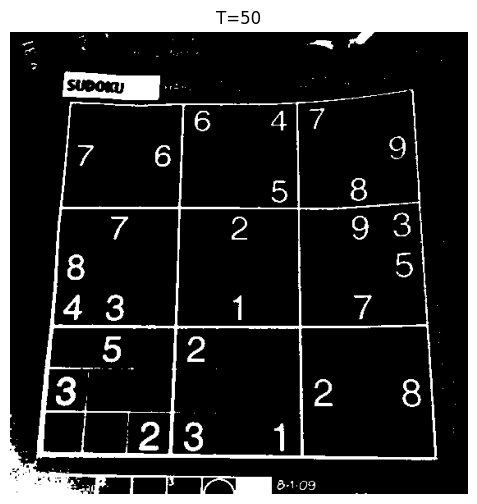

In [12]:
# T=50
T1 = 50

_, global_t1 = cv2.threshold(img,T1,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(8, 6))
plt.imshow(global_t1, cmap="gray")
plt.title("T=50")
plt.axis("off")
plt.show()

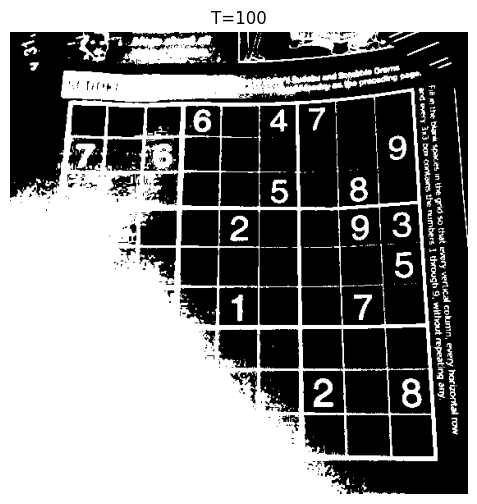

In [13]:
# T=100
T2 = 100

_, global_t2 = cv2.threshold(img,T2,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(8, 6))
plt.imshow(global_t2, cmap="gray")
plt.title("T=100")
plt.axis("off")
plt.show()

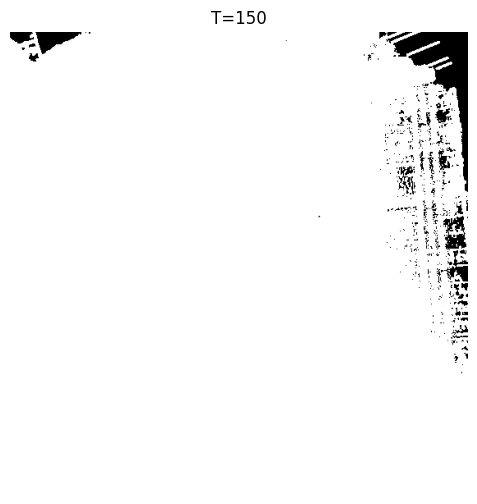

In [14]:
# T=150
T3 = 150

_, global_t3 = cv2.threshold(img,T3,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(8, 6))
plt.imshow(global_t3, cmap="gray")
plt.title("T=150")
plt.axis("off")
plt.show()

Adaptive thresholdd

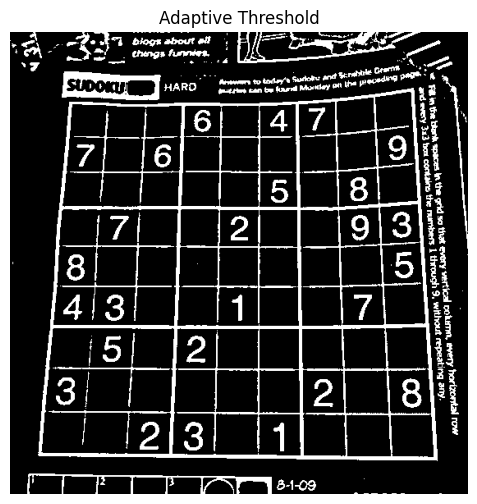

In [15]:
adaptive = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,31,10)

plt.figure(figsize=(8, 6))
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

comparison

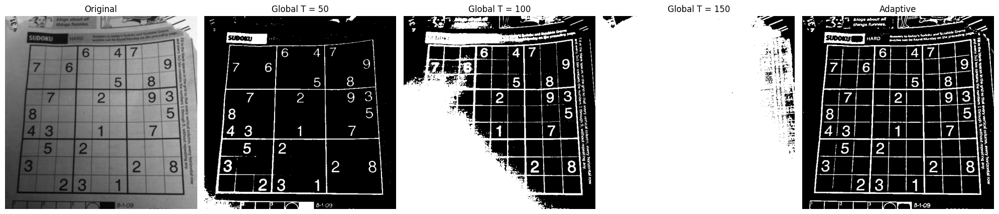

In [16]:
images = [
    img,
    global_t1,
    global_t2,
    global_t3,
    adaptive
]

titles = [
    "Original",
    f"Global T = {T1}",
    f"Global T = {T2}",
    f"Global T = {T3}",
    "Adaptive"
]

plt.figure(figsize=(20, 5))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")


plt.tight_layout()

plt.savefig(
    "output/task1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Global thresholding fails under uneven lighting because dark backgrounds can resemble text intensities. This causes text loss or false foreground detection. Adaptive thresholding works better by using local thresholds that adjust to illumination changes.

The main errors occur in dark or shadowed regions, where background and text intensities become harder to separate.

## Task 2

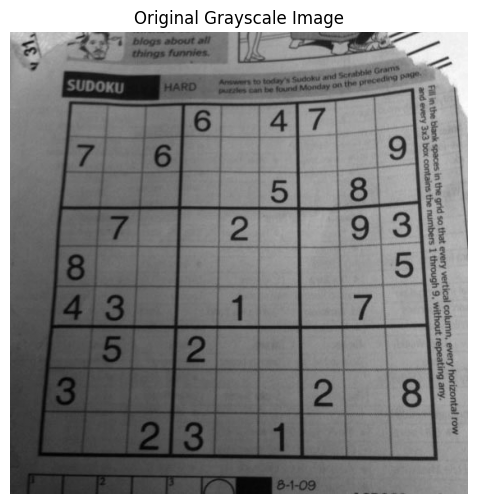

In [18]:
img = cv2.imread("input/sudoku.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found")

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

Mean adaptive threshold

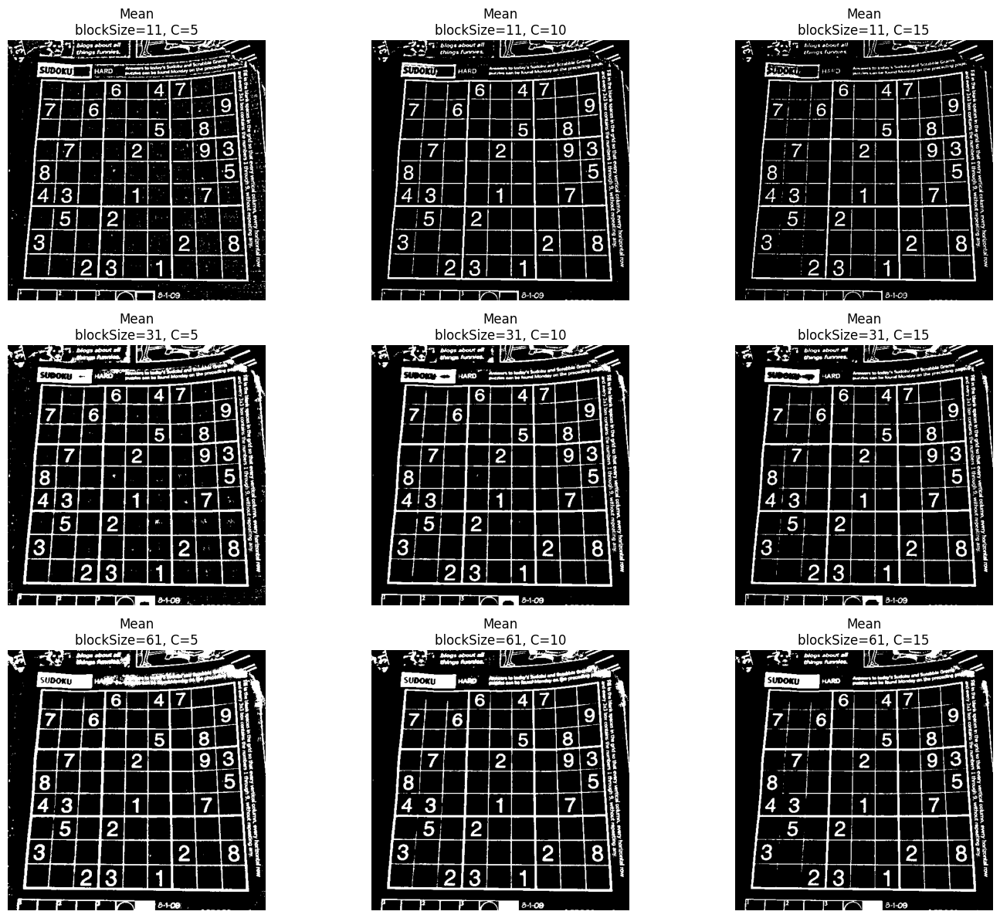

In [19]:
block_sizes = [11, 31, 61]
c_values = [5, 10, 15]

mean_results = {}

plt.figure(figsize=(15, 12))

plot_no = 1

for block_size in block_sizes:
  for C in c_values:

    result = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY_INV,block_size,C)

    mean_results[(block_size, C)] = result

    plt.subplot(3, 3, plot_no)
    plt.imshow(result, cmap="gray")
    plt.title(f"Mean\nblockSize={block_size}, C={C}")
    plt.axis("off")

    plot_no += 1

plt.tight_layout()
plt.show()

Gaussian adaptive threshold

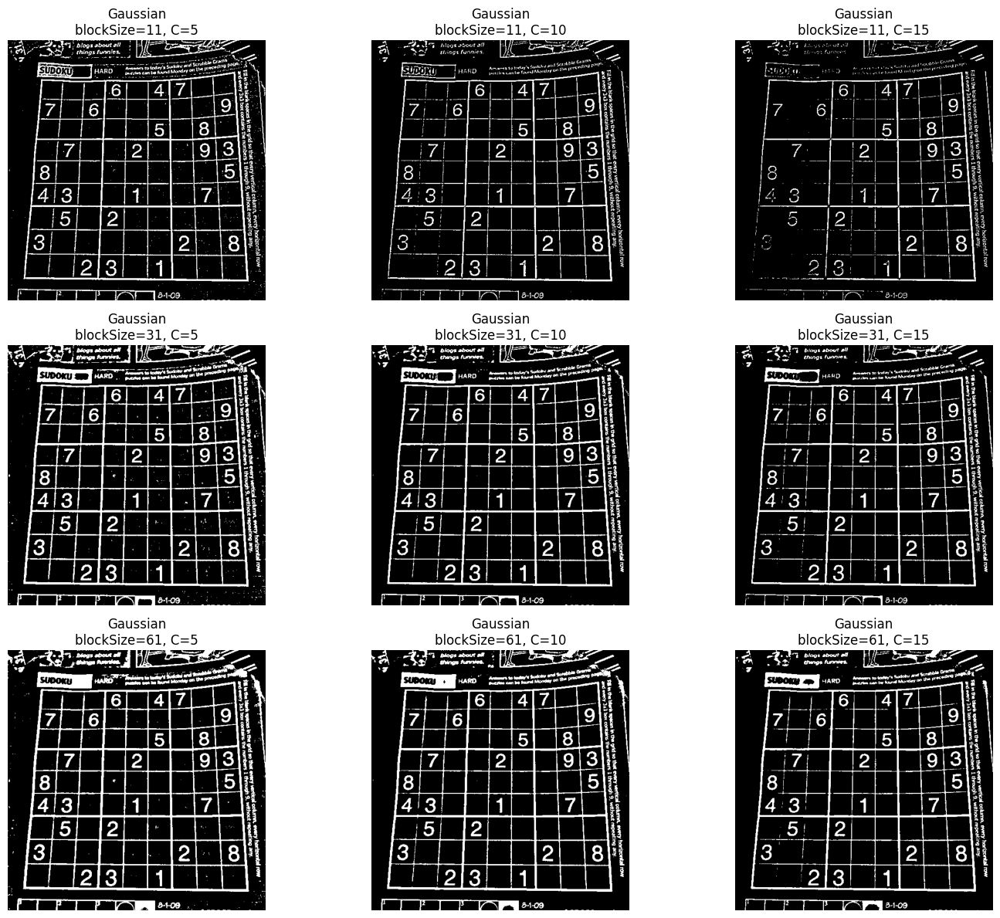

In [20]:
gaussian_results = {}

plt.figure(figsize=(15, 12))

plot_no = 1

for block_size in block_sizes:
  for C in c_values:

    result = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,block_size,C)

    gaussian_results[(block_size, C)] = result

    plt.subplot(3, 3, plot_no)
    plt.imshow(result, cmap="gray")
    plt.title(f"Gaussian\nblockSize={block_size}, C={C}")
    plt.axis("off")

    plot_no += 1

plt.tight_layout()
plt.show()

comparison

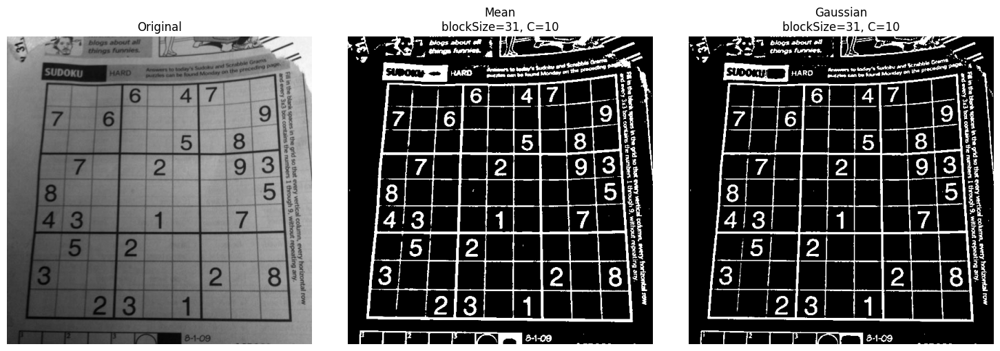

In [21]:
block_size = 31
C = 10

mean_example = mean_results[(block_size, C)]
gaussian_example = gaussian_results[(block_size, C)]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mean_example, cmap="gray")
plt.title("Mean\nblockSize=31, C=10")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian_example, cmap="gray")
plt.title("Gaussian\nblockSize=31, C=10")
plt.axis("off")

plt.tight_layout()
plt.show()

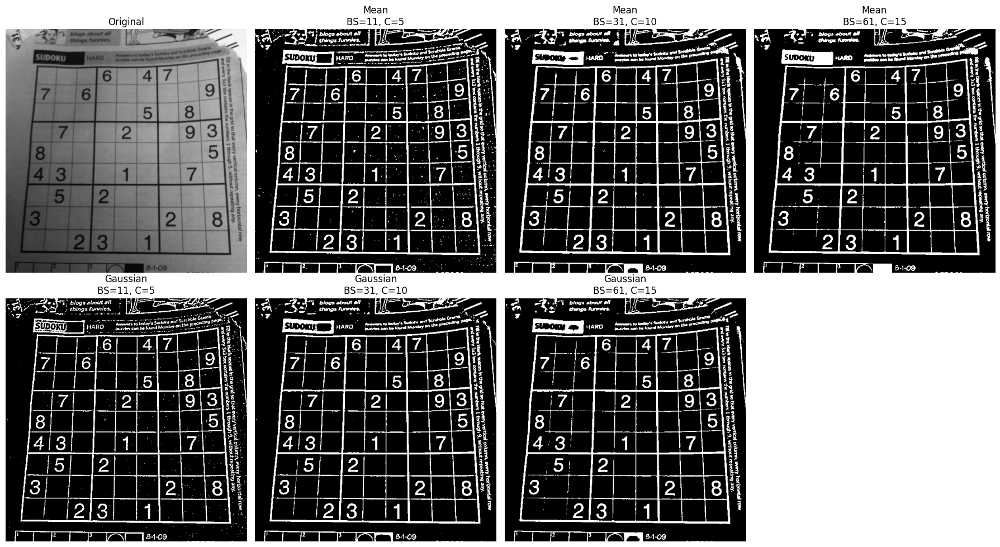

In [22]:
final_results = [
    ("Mean\nBS=11, C=5", mean_results[(11, 5)]),
    ("Mean\nBS=31, C=10", mean_results[(31, 10)]),
    ("Mean\nBS=61, C=15", mean_results[(61, 15)]),

    ("Gaussian\nBS=11, C=5", gaussian_results[(11, 5)]),
    ("Gaussian\nBS=31, C=10", gaussian_results[(31, 10)]),
    ("Gaussian\nBS=61, C=15", gaussian_results[(61, 15)])
]

plt.figure(figsize=(18, 10))

# Original
plt.subplot(2, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

# Six threshold results
for i, (title, result) in enumerate(final_results, start=2):
    plt.subplot(2, 4, i)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A very small blockSize is sensitive to noise and may produce broken or noisy text. A very large blockSize may fail to adapt to local lighting changes.

Increasing C lowers the threshold, which helps remove background noise. However, a very large C may also remove valid text pixels.

Gaussian adaptive thresholding with blockSize = 31 and C = 10 gave the best result, balancing noise removal and text preservation.

Gaussian thresholding performed better because it gives more weight to nearby pixels, allowing smoother adaptation to uneven illumination.

## Task 3

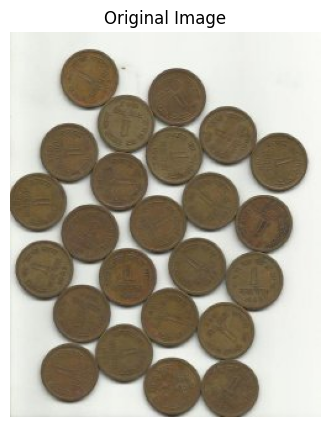

In [25]:
image = cv2.imread("input/coins.jpg")

if image is None:
    raise FileNotFoundError("Image not found")

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

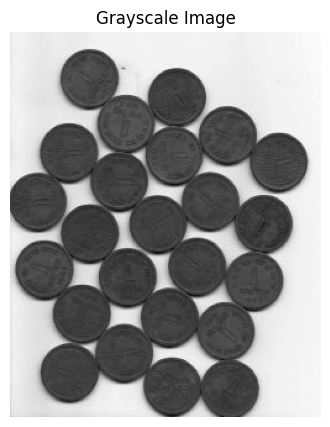

In [26]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

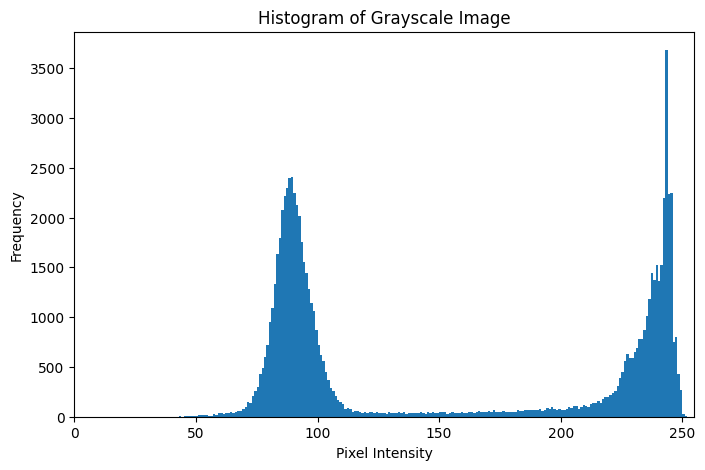

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(gray.ravel(),bins=256,range=[0, 256])

plt.title("Histogram of Grayscale Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 255])
plt.show()

In [28]:
otsu_threshold, otsu_mask = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Automatically selected Otsu threshold:", otsu_threshold)

Automatically selected Otsu threshold: 162.0


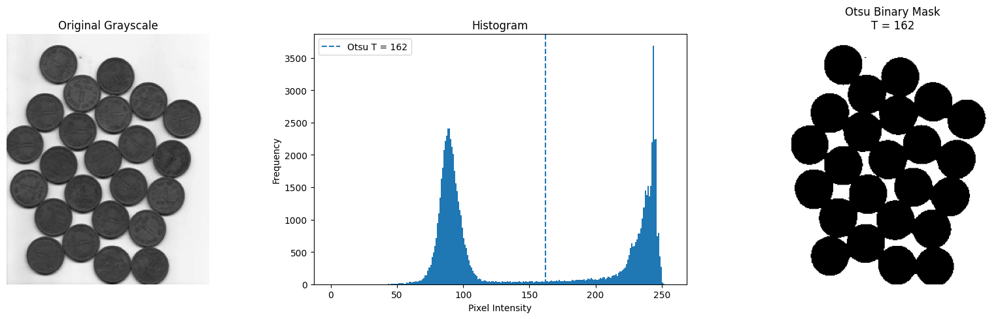

In [29]:
plt.figure(figsize=(18, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

# Histogram
plt.subplot(1, 3, 2)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.axvline(otsu_threshold,linestyle="--",label=f"Otsu T = {otsu_threshold:.0f}"
)
plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

# Binary mask
plt.subplot(1, 3, 3)
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Otsu Binary Mask\nT = {otsu_threshold:.0f}")
plt.axis("off")

plt.tight_layout()
plt.show()

increasing contrast

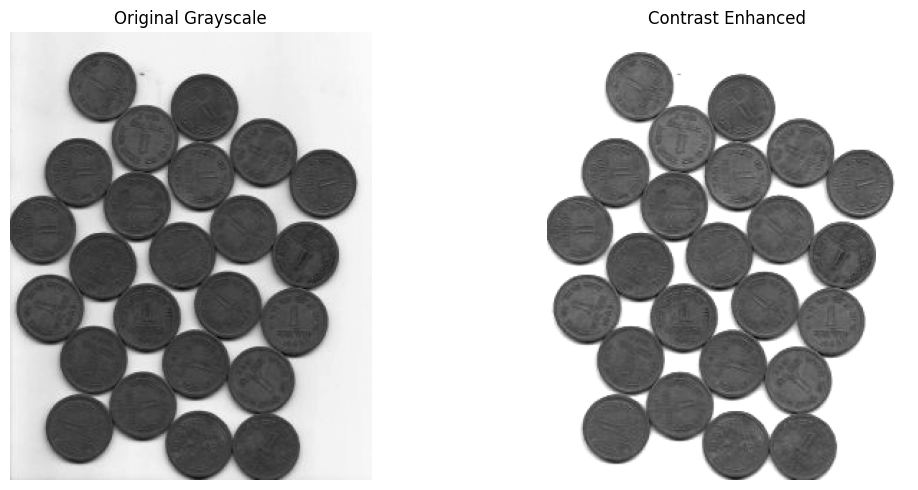

In [30]:
contrast_gray = cv2.convertScaleAbs(gray,alpha=1.3,beta=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(contrast_gray, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
otsu_threshold_contrast, otsu_mask_contrast = cv2.threshold(contrast_gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Original Otsu threshold:", otsu_threshold)
print("Contrast-enhanced Otsu threshold:", otsu_threshold_contrast)
print(f"Difference:{otsu_threshold_contrast - otsu_threshold:.2f}")

Original Otsu threshold: 162.0
Contrast-enhanced Otsu threshold: 183.0
Difference:21.00


compare

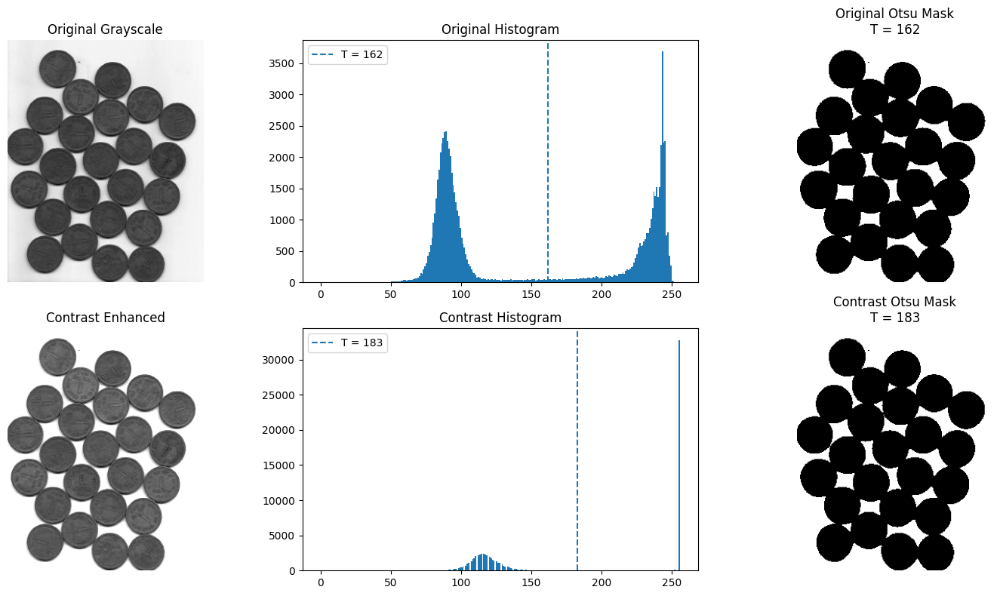

In [32]:
plt.figure(figsize=(16, 8))

# Original grayscale
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

# Original histogram
plt.subplot(2, 3, 2)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.axvline(otsu_threshold,linestyle="--",label=f"T = {otsu_threshold:.0f}")
plt.title("Original Histogram")
plt.legend()

# Original mask
plt.subplot(2, 3, 3)
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Original Otsu Mask\nT = {otsu_threshold:.0f}")
plt.axis("off")


# Contrast image
plt.subplot(2, 3, 4)
plt.imshow(contrast_gray, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

# Contrast histogram
plt.subplot(2, 3, 5)
plt.hist(contrast_gray.ravel(), bins=256, range=[0, 256])
plt.axvline(otsu_threshold_contrast,linestyle="--",label=f"T = {otsu_threshold_contrast:.0f}")
plt.title("Contrast Histogram")
plt.legend()

# Contrast mask
plt.subplot(2, 3, 6)
plt.imshow(otsu_mask_contrast, cmap="gray")
plt.title(f"Contrast Otsu Mask\nT = {otsu_threshold_contrast:.0f}")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Otsu’s thresholding automatically selects a suitable threshold from the image histogram, avoiding manual tuning. It works best when foreground and background form distinct intensity groups.

After contrast enhancement, the intensity distribution changed, so Otsu selected a new threshold automatically. This shows its ability to adapt to changes in image intensity.

## Task 4

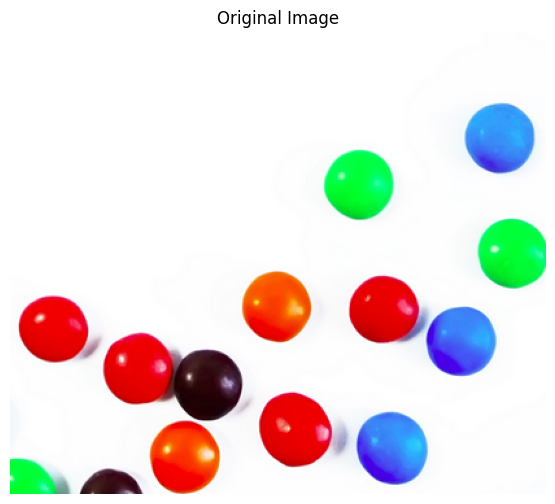

In [104]:
image = cv2.imread("input/smarties.png")

if image is None:
    raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

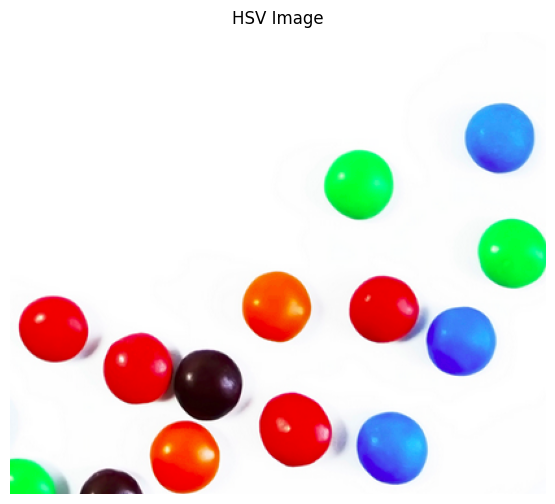

In [105]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV Image")
plt.axis("off")
plt.show()

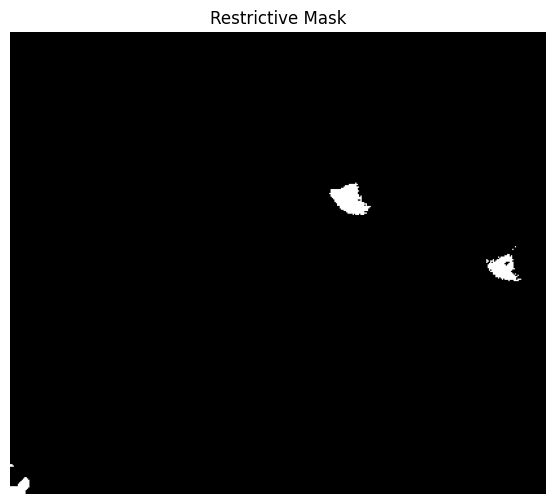

In [106]:
lower_restrictive = np.array([55, 180, 180])
upper_restrictive = np.array([65, 255, 255])


restrictive_mask = cv2.inRange(hsv,lower_restrictive,upper_restrictive)

plt.figure(figsize=(8, 6))
plt.imshow(restrictive_mask, cmap="gray")
plt.title("Restrictive Mask")
plt.axis("off")
plt.show()

improved final mask

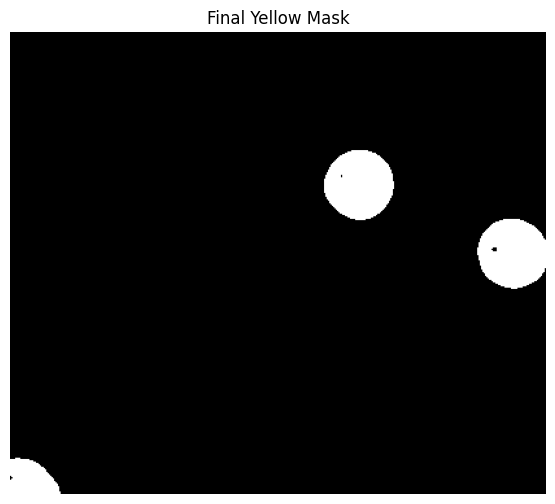

In [107]:
lower_final = np.array([40, 80, 80])
upper_final = np.array([85, 255, 255])


final_mask = cv2.inRange(hsv,lower_final,upper_final)

plt.figure(figsize=(8, 6))
plt.imshow(final_mask, cmap="gray")
plt.title("Final Yellow Mask")
plt.axis("off")
plt.show()

compare

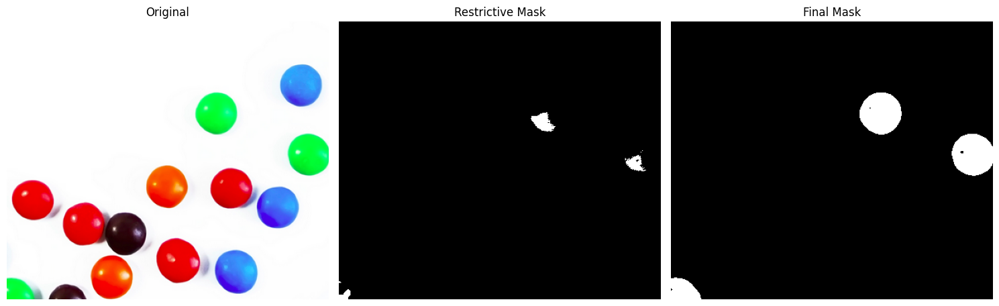

In [108]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restrictive_mask, cmap="gray")
plt.title("Restrictive Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_mask, cmap="gray")
plt.title("Final Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

extract the selected color

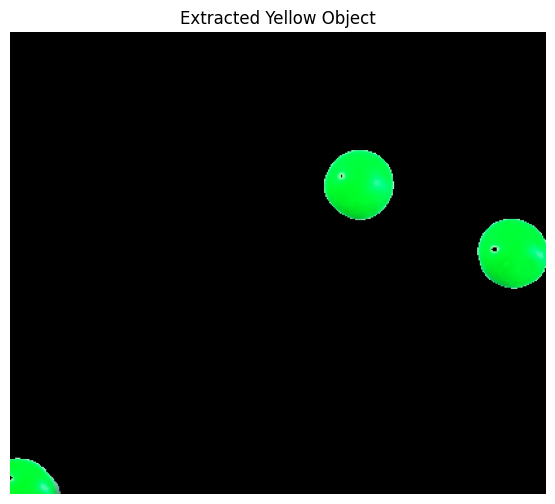

In [109]:
extracted = cv2.bitwise_and(image,image,mask=final_mask)

extracted_rgb = cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(extracted_rgb)
plt.title("Extracted Yellow Object")
plt.axis("off")
plt.show()

In [110]:
restrictive_extracted = cv2.bitwise_and(image,image,mask=restrictive_mask)

restrictive_extracted_rgb = cv2.cvtColor(restrictive_extracted,cv2.COLOR_BGR2RGB)

compare

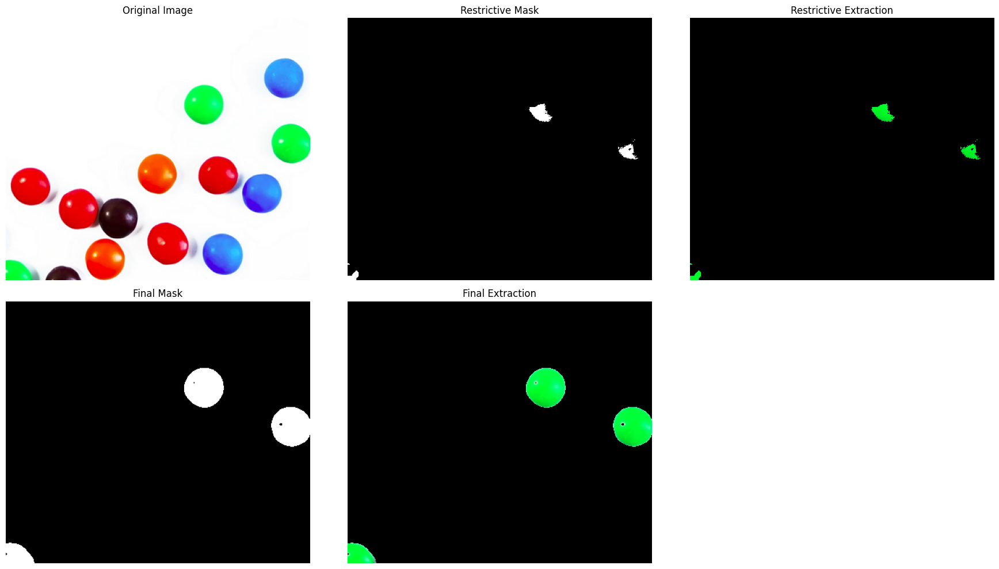

In [111]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(restrictive_mask, cmap="gray")
plt.title("Restrictive Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(restrictive_extracted_rgb)
plt.title("Restrictive Extraction")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(final_mask, cmap="gray")
plt.title("Final Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(extracted_rgb)
plt.title("Final Extraction")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A restrictive HSV mask fails because lighting, shadows, and reflections cause HSV values to vary across the same object. A narrow range therefore removes valid object pixels.

Using a wider hue range with lower saturation and value limits captures darker and less saturated yellow regions, producing a more complete mask.

## Task 5

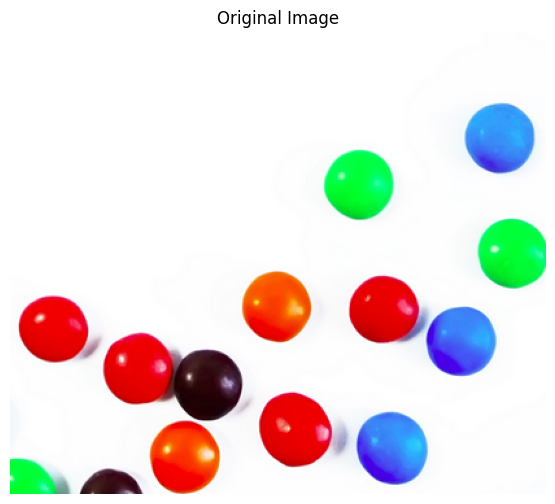

In [41]:
image = cv2.imread("input/smarties.png")

if image is None:
    raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

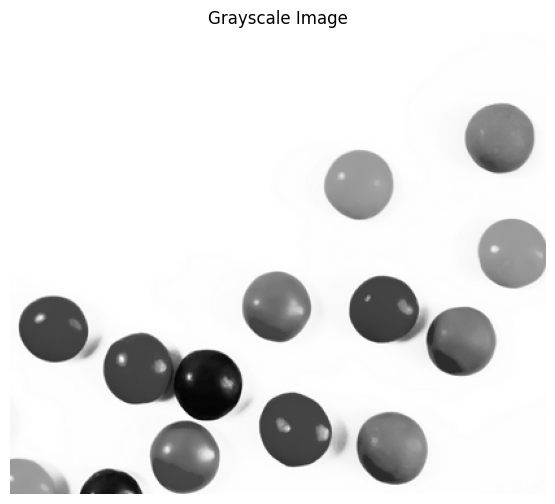

In [42]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

slight noise reduction

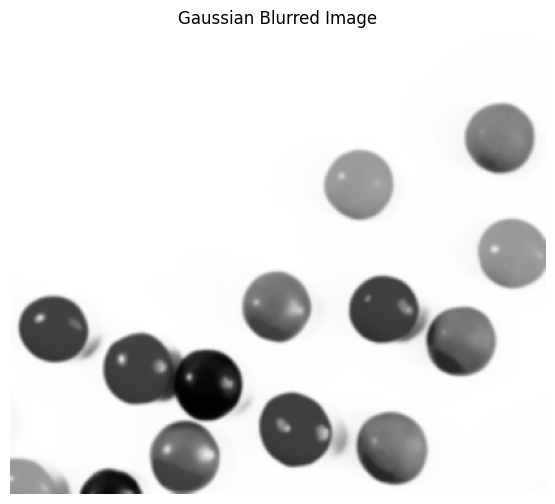

In [43]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

low high threshold

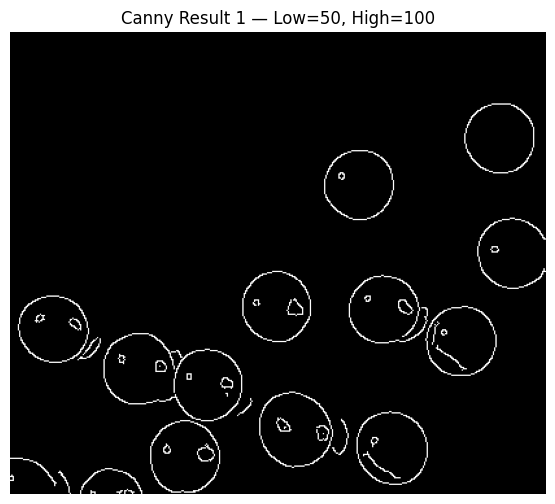

In [44]:
low1 = 50
high1 = 100

edges1 = cv2.Canny(blurred,low1,high1)

plt.figure(figsize=(8, 6))
plt.imshow(edges1, cmap="gray")
plt.title("Canny Result 1 — Low=50, High=100")
plt.axis("off")
plt.show()

moderate high threshold

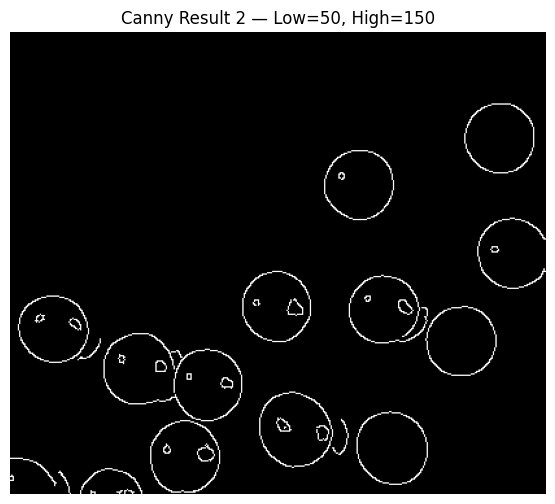

In [45]:
low2 = 50
high2 = 150

edges2 = cv2.Canny(blurred,low2,high2)

plt.figure(figsize=(8, 6))
plt.imshow(edges2, cmap="gray")
plt.title("Canny Result 2 — Low=50, High=150")
plt.axis("off")
plt.show()

high high threshold

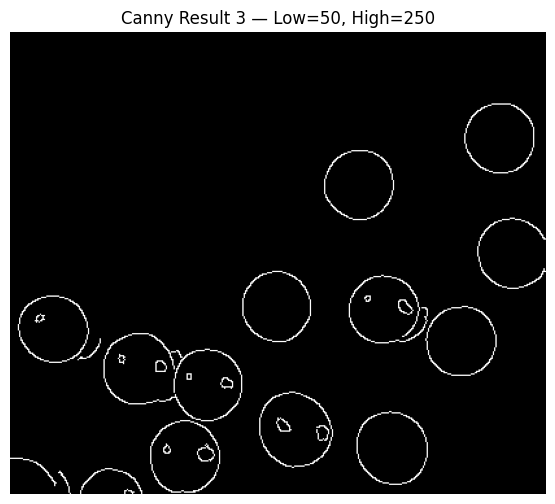

In [46]:
low3 = 50
high3 = 250

edges3 = cv2.Canny(blurred,low3,high3)

plt.figure(figsize=(8, 6))
plt.imshow(edges3, cmap="gray")
plt.title("Canny Result 3 — Low=50, High=250")
plt.axis("off")
plt.show()

comparison

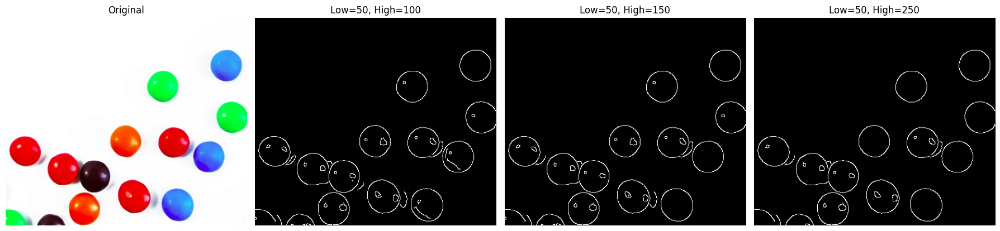

In [47]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(edges1, cmap="gray")
plt.title("Low=50, High=100")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(edges2, cmap="gray")
plt.title("Low=50, High=150")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edges3, cmap="gray")
plt.title("Low=50, High=250")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Strong edges have large intensity changes and remain visible at higher thresholds. Weak edges are kept only when connected to strong edges.

Very high thresholds can remove genuine weak boundaries, causing missing edges. Very low thresholds detect noise and texture, producing unwanted edges.

With Canny, 50–100 detected extra noise, while 50–250 removed some genuine boundaries. 50–150 provided the best balance between preserving the object boundary and suppressing unwanted edges.

## Task 6

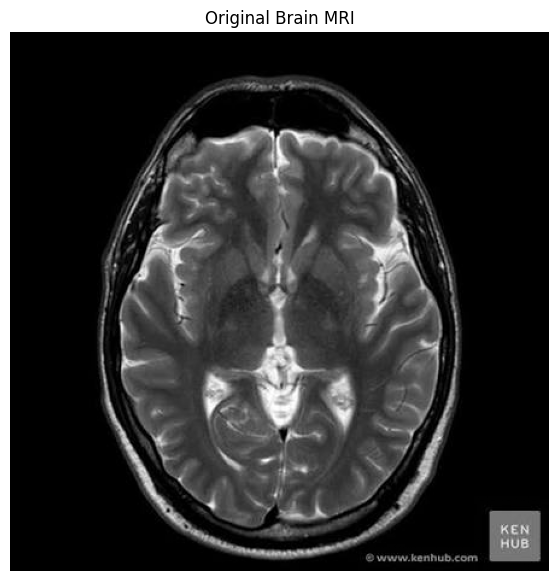

In [112]:
image = cv2.imread("input/brain_mri.jfif", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found")

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
plt.title("Original Brain MRI")
plt.axis("off")
plt.show()

In [113]:
def region_growing(image, seed, threshold):
  # Binary output mask
  mask = np.zeros_like(image, dtype=np.uint8)

  # Tracks pixels that have already been checked
  visited = np.zeros_like(image, dtype=bool)

  # Seed is given as (x, y)
  seed_x, seed_y = seed

  # Intensity at the starting point
  seed_intensity = int(image[seed_y, seed_x])

  # Stack stores pixels that still need to be examined
  stack = [(seed_x, seed_y)]

  height, width = image.shape

  while stack:

    x, y = stack.pop()

    # Ignore pixels outside image boundaries
    if x < 0 or x >= width or y < 0 or y >= height:
      continue

    # Do not process same pixel repeatedly
    if visited[y, x]:
      continue

    visited[y, x] = True

    current_intensity = int(image[y, x])

    # Compare current pixel with seed intensity
    if abs(current_intensity - seed_intensity) <= threshold:

      # Add pixel to segmented region
      mask[y, x] = 255

      # Add 4-connected neighbours
      stack.append((x + 1, y))
      stack.append((x - 1, y))
      stack.append((x, y + 1))
      stack.append((x, y - 1))

  return mask

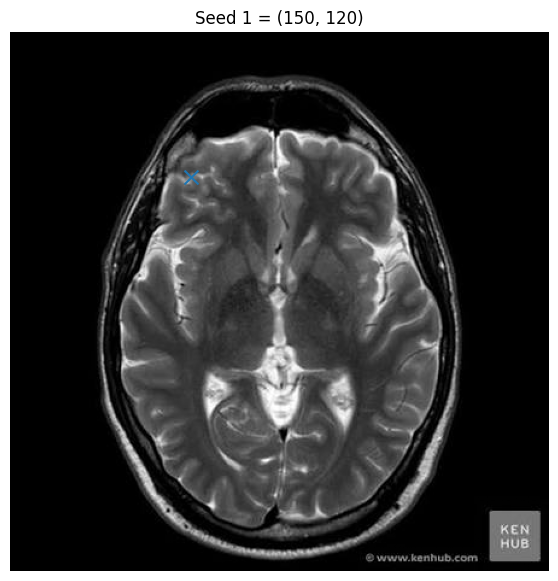

In [114]:
seed1 = (150, 120)

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")

plt.scatter(seed1[0],seed1[1],marker="x",s=100)

plt.title(f"Seed 1 = {seed1}")
plt.axis("off")
plt.show()

Test three thresholds

In [115]:
thresholds = [10, 25, 50]

seed1_results = []

for threshold in thresholds:
  mask = region_growing(image,seed1,threshold)

  seed1_results.append(mask)

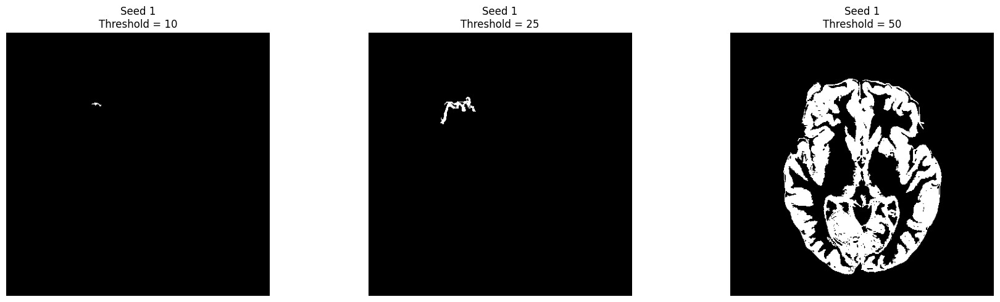

In [116]:
plt.figure(figsize=(18, 5))

for i, threshold in enumerate(thresholds):

  plt.subplot(1, 3, i + 1)
  plt.imshow(seed1_results[i], cmap="gray")
  plt.title(f"Seed 1\nThreshold = {threshold}")
  plt.axis("off")

plt.tight_layout()
plt.show()

with another seed

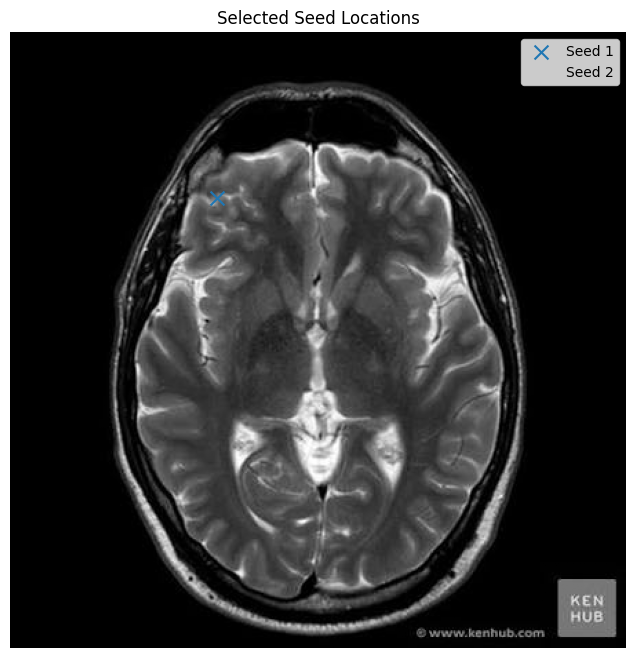

In [117]:
seed2 = (220, 170)

plt.figure(figsize=(8, 8))

plt.imshow(image, cmap="gray")

plt.scatter(seed1[0], seed1[1],marker="x",s=100,label="Seed 1")

plt.scatter(seed2[0], seed2[1],marker="o",s=80,facecolors="none",label="Seed 2")

plt.title("Selected Seed Locations")
plt.legend()
plt.axis("off")
plt.show()

In [118]:
seed2_results = []

for threshold in thresholds:
  mask = region_growing(image,seed2,threshold)

  seed2_results.append(mask)

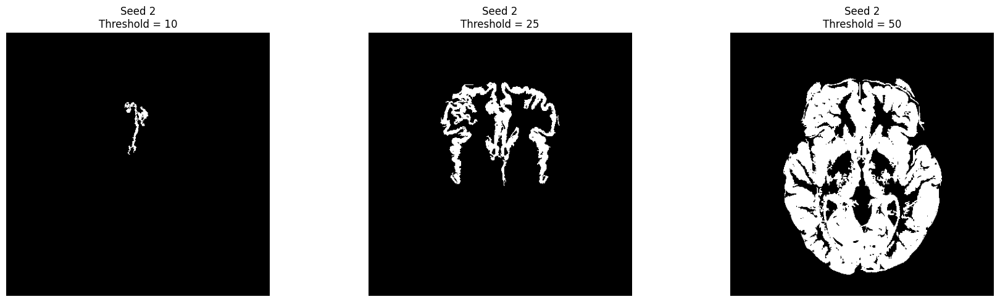

In [119]:
plt.figure(figsize=(18, 5))

for i, threshold in enumerate(thresholds):

  plt.subplot(1, 3, i + 1)
  plt.imshow(seed2_results[i], cmap="gray")
  plt.title(f"Seed 2\nThreshold = {threshold}")
  plt.axis("off")

plt.tight_layout()
plt.show()

comparison

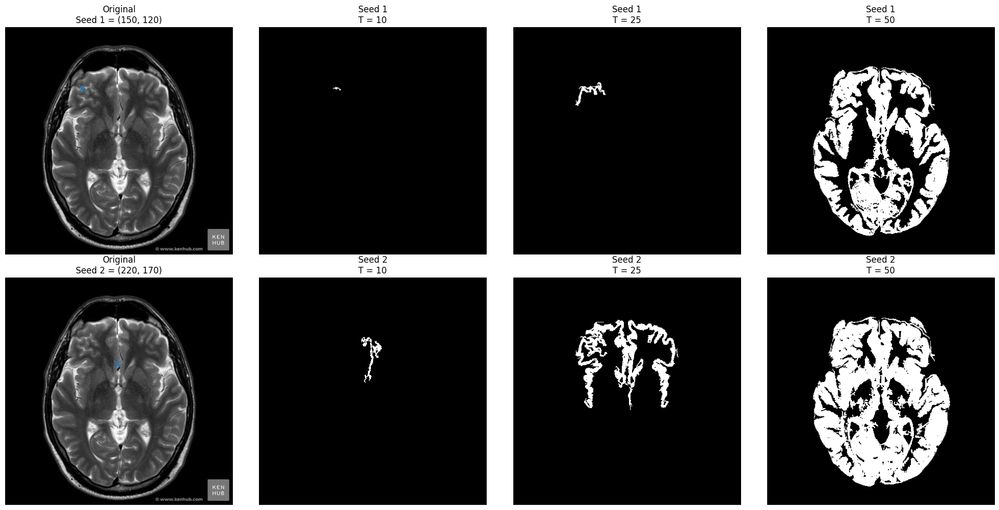

In [122]:
plt.figure(figsize=(20, 10))

# Original with Seed 1
plt.subplot(2, 4, 1)
plt.imshow(image, cmap="gray")
plt.scatter(seed1[0], seed1[1], marker="x", s=100)
plt.title(f"Original\nSeed 1 = {seed1}")
plt.axis("off")

# Seed 1 results
for i, threshold in enumerate(thresholds):

  plt.subplot(2, 4, i + 2)
  plt.imshow(seed1_results[i], cmap="gray")
  plt.title(f"Seed 1\nT = {threshold}")
  plt.axis("off")


# Original with Seed 2
plt.subplot(2, 4, 5)
plt.imshow(image, cmap="gray")
plt.scatter(seed2[0], seed2[1], marker="x", s=100)
plt.title(f"Original\nSeed 2 = {seed2}")
plt.axis("off")

# Seed 2 results
for i, threshold in enumerate(thresholds):

  plt.subplot(2, 4, i + 6)
  plt.imshow(seed2_results[i], cmap="gray")
  plt.title(f"Seed 2\nT = {threshold}")
  plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 7

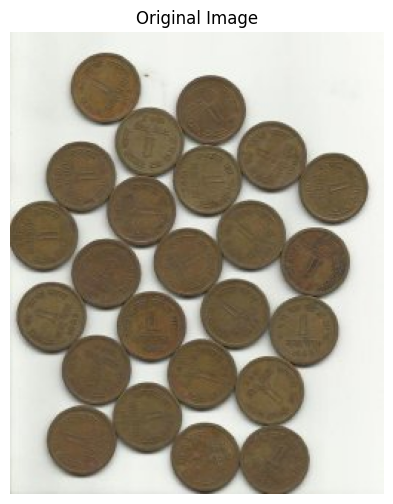

In [51]:
image = cv2.imread("input/coins.jpg")

if image is None:
  raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

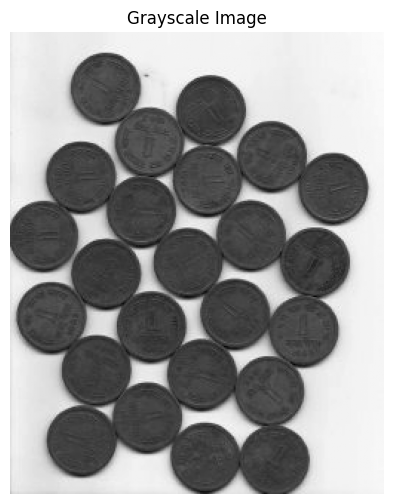

In [52]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

thresholding

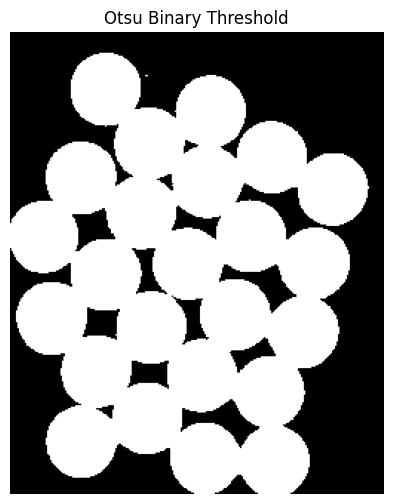

In [53]:
_, threshold = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(8, 6))
plt.imshow(threshold, cmap="gray")
plt.title("Otsu Binary Threshold")
plt.axis("off")
plt.show()

noise removal

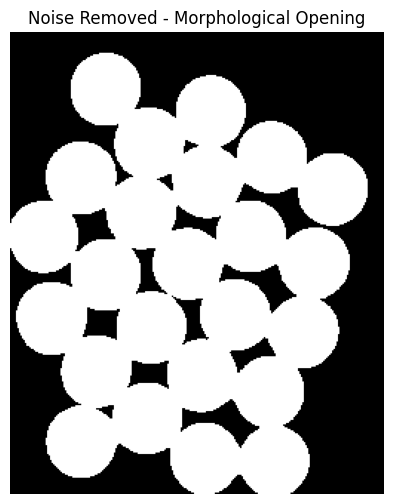

In [54]:
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(threshold,cv2.MORPH_OPEN,kernel,iterations=2)

plt.figure(figsize=(8, 6))
plt.imshow(opening, cmap="gray")
plt.title("Noise Removed - Morphological Opening")
plt.axis("off")
plt.show()

sure background

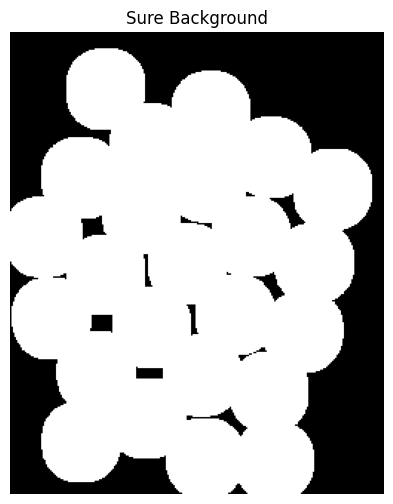

In [55]:
sure_bg = cv2.dilate(opening,kernel,iterations=3)

plt.figure(figsize=(8, 6))
plt.imshow(sure_bg, cmap="gray")
plt.title("Sure Background")
plt.axis("off")
plt.show()

distance transform

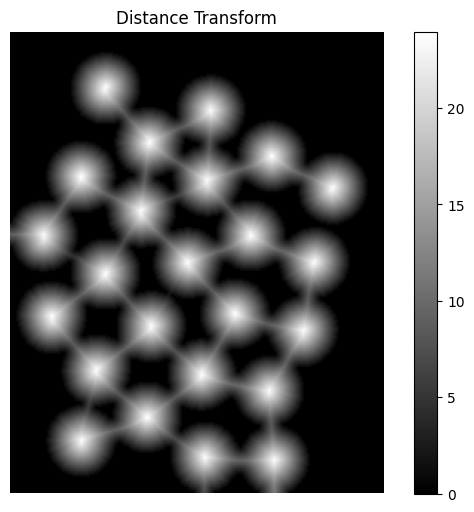

In [56]:
distance_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

plt.figure(figsize=(8, 6))
plt.imshow(distance_transform, cmap="gray")
plt.title("Distance Transform")
plt.axis("off")
plt.colorbar()
plt.show()

sure foreground

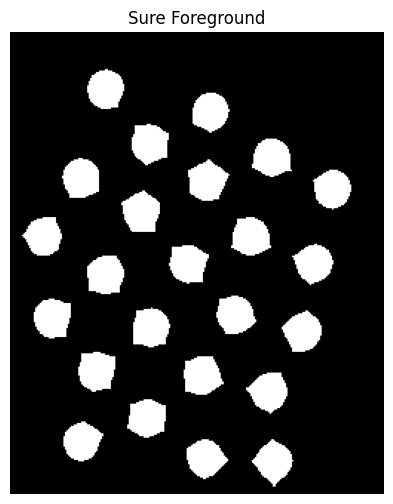

In [57]:
_, sure_fg = cv2.threshold(distance_transform,0.5 * distance_transform.max(),255,0)

sure_fg = np.uint8(sure_fg)

plt.figure(figsize=(8, 6))
plt.imshow(sure_fg, cmap="gray")
plt.title("Sure Foreground")
plt.axis("off")
plt.show()

unknown regoin

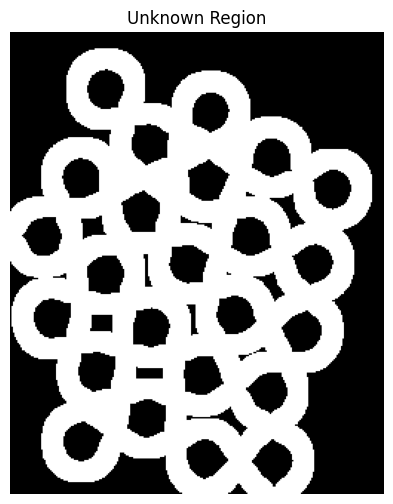

In [58]:
unknown = cv2.subtract(sure_bg,sure_fg)

plt.figure(figsize=(8, 6))
plt.imshow(unknown, cmap="gray")
plt.title("Unknown Region")
plt.axis("off")
plt.show()

In [59]:
num_labels, markers = cv2.connectedComponents(sure_fg)

print("Connected components found:", num_labels)

Connected components found: 25


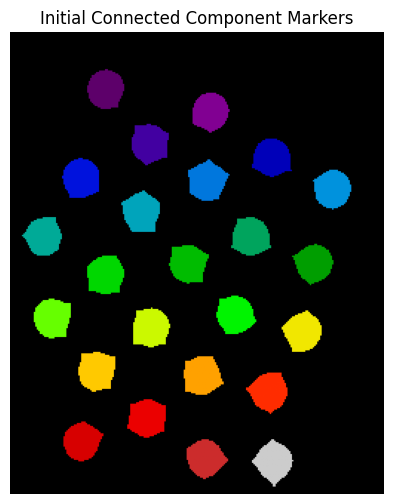

In [60]:
plt.figure(figsize=(8, 6))
plt.imshow(markers, cmap="nipy_spectral")
plt.title("Initial Connected Component Markers")
plt.axis("off")
plt.show()

watershed markers

In [61]:
markers = markers + 1
markers[unknown == 255] = 0

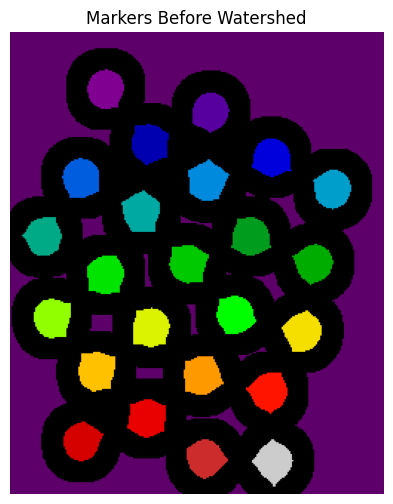

In [62]:
plt.figure(figsize=(8, 6))
plt.imshow(markers, cmap="nipy_spectral")
plt.title("Markers Before Watershed")
plt.axis("off")
plt.show()

In [63]:
watershed_markers = cv2.watershed(image.copy(),markers)

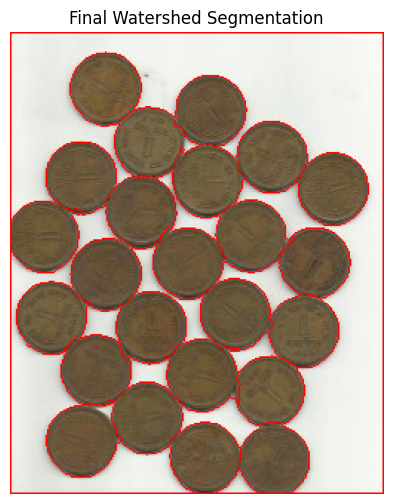

In [64]:
result = image.copy()

result[watershed_markers == -1] = [0, 0, 255]

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(result_rgb)
plt.title("Final Watershed Segmentation")
plt.axis("off")
plt.show()

comparison

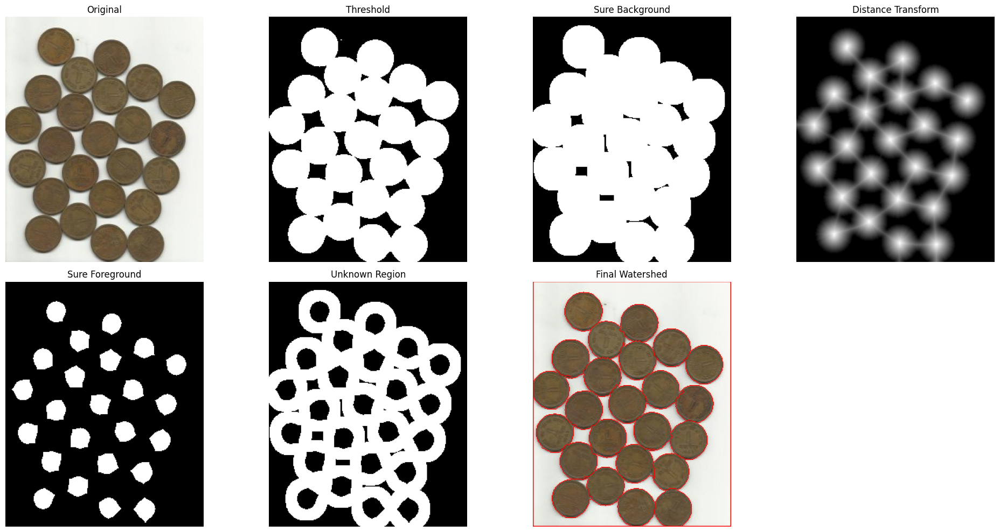

In [65]:
plt.figure(figsize=(20, 10))

# 1. Original
plt.subplot(2, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

# 2. Threshold
plt.subplot(2, 4, 2)
plt.imshow(threshold, cmap="gray")
plt.title("Threshold")
plt.axis("off")

# 3. Sure background
plt.subplot(2, 4, 3)
plt.imshow(sure_bg, cmap="gray")
plt.title("Sure Background")
plt.axis("off")

# 4. Distance transform
plt.subplot(2, 4, 4)
plt.imshow(distance_transform, cmap="gray")
plt.title("Distance Transform")
plt.axis("off")

# 5. Sure foreground
plt.subplot(2, 4, 5)
plt.imshow(sure_fg, cmap="gray")
plt.title("Sure Foreground")
plt.axis("off")

# 6. Unknown region
plt.subplot(2, 4, 6)
plt.imshow(unknown, cmap="gray")
plt.title("Unknown Region")
plt.axis("off")

# 7. Final watershed
plt.subplot(2, 4, 7)
plt.imshow(result_rgb)
plt.title("Final Watershed")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task7.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
object_labels = np.unique(watershed_markers)

print("Unique watershed labels:", object_labels)

Unique watershed labels: [-1  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [67]:
coin_labels = object_labels[object_labels > 1]
coin_count = len(coin_labels)

print("Estimated number of coins:", coin_count)

Estimated number of coins: 24


The initial binary threshold merged touching coins into connected foreground regions. After applying the distance transform, separate high-distance regions appeared near the centers of individual coins. These regions were used as foreground markers for marker-based watershed segmentation. Watershed then assigned neighbouring pixels to their corresponding markers and created boundaries where adjacent regions met. As a result, the touching coins were separated into distinct regions.

## Task 8

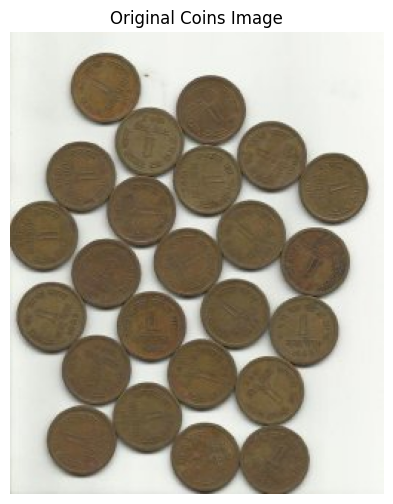

In [68]:
image = cv2.imread("input/coins.jpg")

if image is None:
    raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Coins Image")
plt.axis("off")
plt.show()

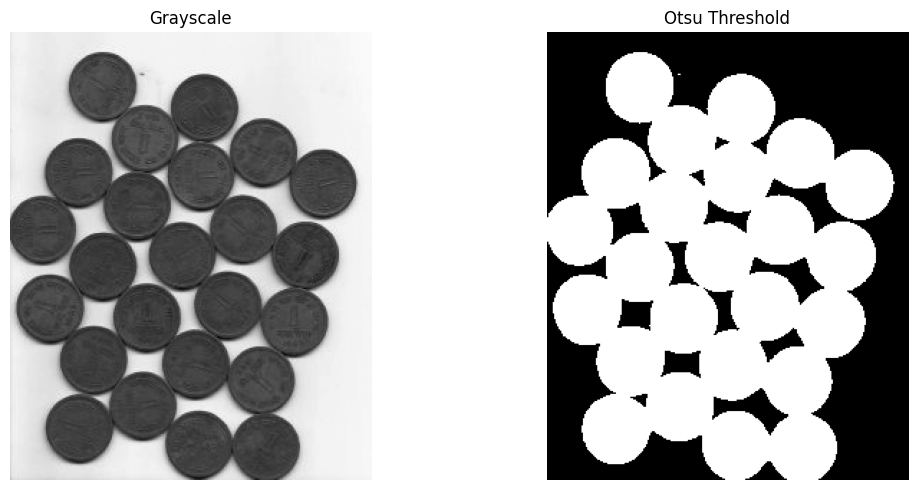

In [69]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, threshold = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(threshold, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

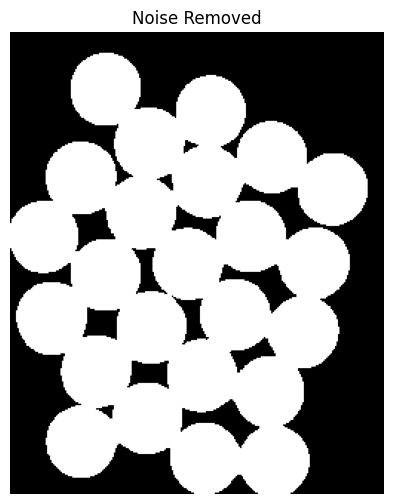

In [70]:
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(threshold,cv2.MORPH_OPEN,kernel,iterations=2)

plt.figure(figsize=(8, 6))
plt.imshow(opening, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.show()

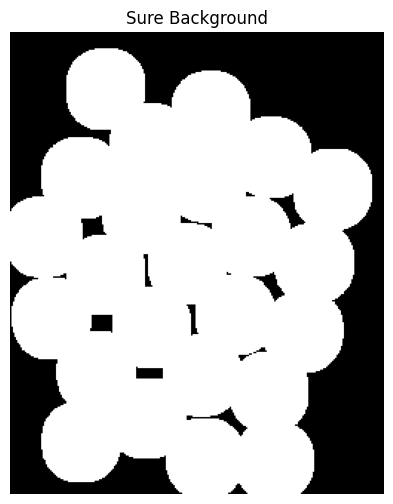

In [71]:
sure_bg = cv2.dilate(opening,kernel,iterations=3)

plt.figure(figsize=(8, 6))
plt.imshow(sure_bg, cmap="gray")
plt.title("Sure Background")
plt.axis("off")
plt.show()

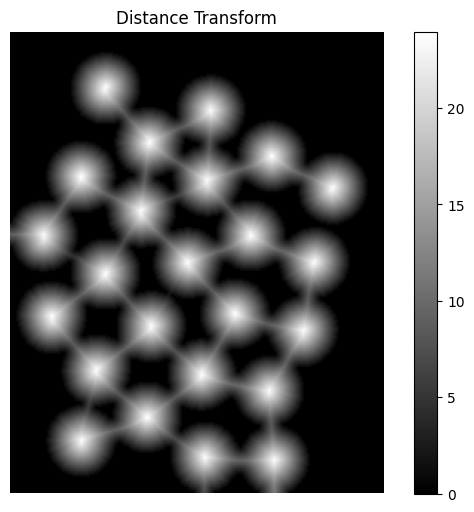

In [72]:
distance_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

plt.figure(figsize=(8, 6))
plt.imshow(distance_transform, cmap="gray")
plt.title("Distance Transform")
plt.colorbar()
plt.axis("off")
plt.show()

In [73]:
def watershed_experiment(image,sure_bg,distance_transform,threshold_factor):
    # Generate sure foreground
  _, sure_fg = cv2.threshold(distance_transform,threshold_factor * distance_transform.max(),255,0)

  sure_fg = np.uint8(sure_fg)

  # Unknown region
  unknown = cv2.subtract(sure_bg, sure_fg)

  # Label foreground markers
  num_labels, markers = cv2.connectedComponents(sure_fg)

  foreground_markers = num_labels - 1

  # Prepare markers for watershed
  markers = markers + 1
  markers[unknown == 255] = 0

  # Apply watershed
  watershed_markers = cv2.watershed(image.copy(),markers)

  # Count final separated object regions
  object_labels = np.unique(watershed_markers)
  separated_regions = np.sum(object_labels > 1)

  # Draw watershed boundaries
  result = image.copy()
  result[watershed_markers == -1] = [0, 0, 255]

  return (sure_fg,unknown,watershed_markers,result,foreground_markers,separated_regions)

experiments

In [74]:
threshold_factors = [0.30, 0.40, 0.50, 0.60]

experiments = []

for factor in threshold_factors:

  (sure_fg,unknown,watershed_markers,result,foreground_markers,separated_regions) = watershed_experiment(image,sure_bg,distance_transform,factor)

  experiments.append({
    "factor": factor,
    "sure_fg": sure_fg,
    "unknown": unknown,
    "markers": watershed_markers,
    "result": result,
    "foreground_markers": foreground_markers,
    "separated_regions": separated_regions
    })

In [75]:
print(
  f"{'Experiment':<12}"
  f"{'Threshold':<15}"
  f"{'FG Markers':<15}"
  f"{'Regions':<10}"
)

print("-" * 52)

for i, exp in enumerate(experiments, start=1):

  print(
    f"{i:<12}"
    f"{exp['factor']:<15.2f}"
    f"{exp['foreground_markers']:<15}"
    f"{exp['separated_regions']:<10}"
  )

Experiment  Threshold      FG Markers     Regions   
----------------------------------------------------
1           0.30           2              2         
2           0.40           27             27        
3           0.50           24             24        
4           0.60           24             24        


compare foreground

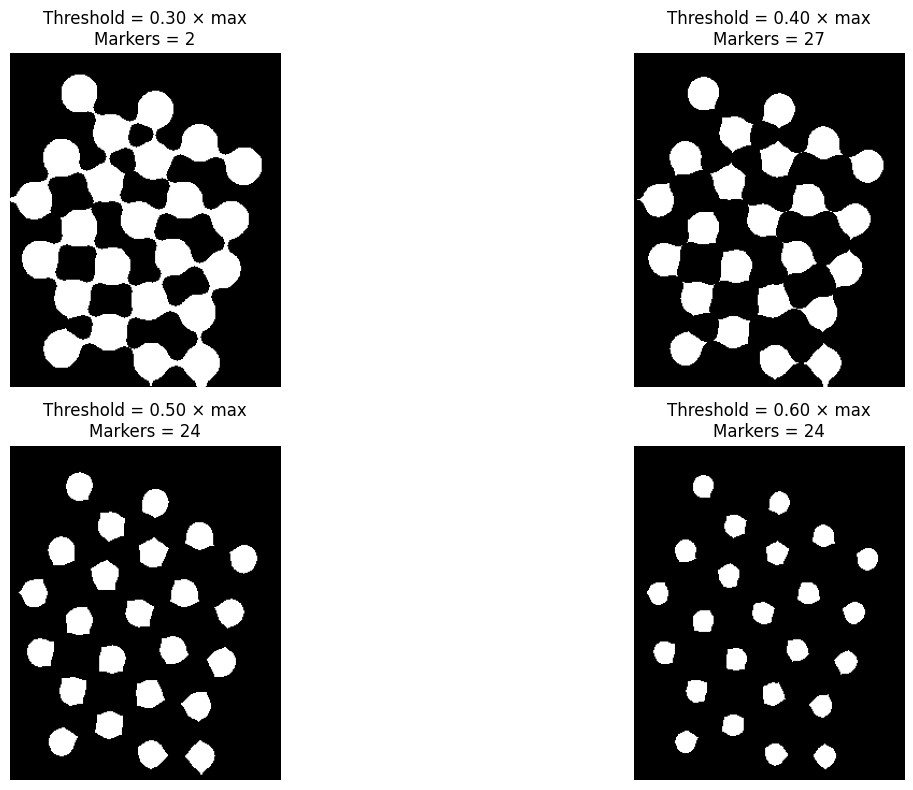

In [76]:
plt.figure(figsize=(16, 8))

for i, exp in enumerate(experiments):

    plt.subplot(2, 2, i + 1)

    plt.imshow(
        exp["sure_fg"],
        cmap="gray"
    )

    plt.title(
        f"Threshold = {exp['factor']:.2f} × max\n"
        f"Markers = {exp['foreground_markers']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

compare final results

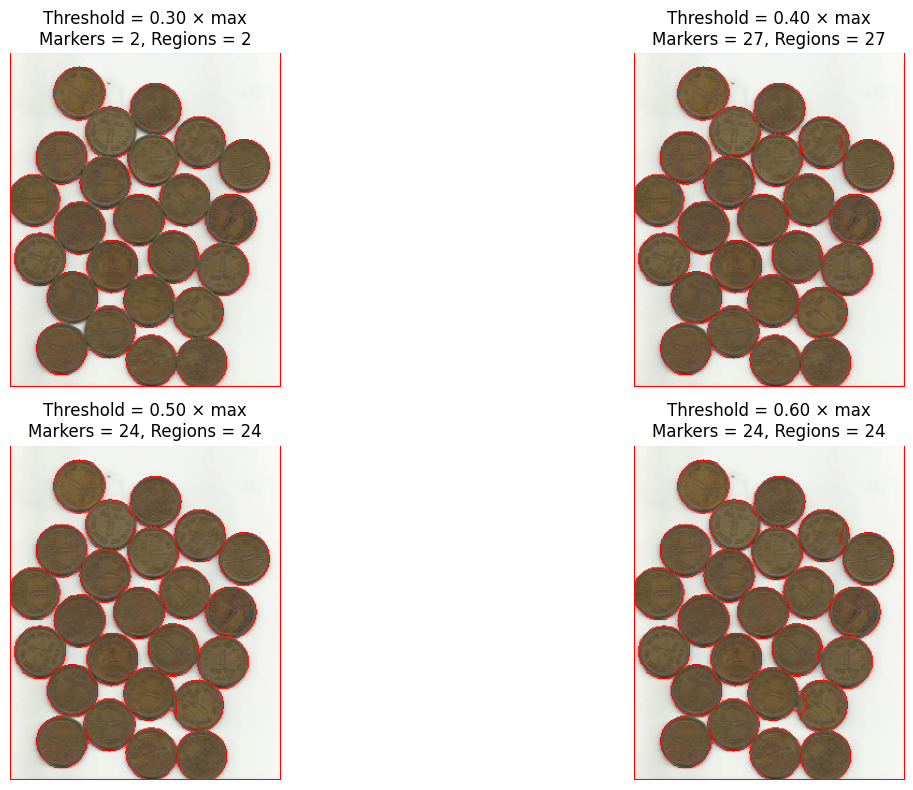

In [77]:
plt.figure(figsize=(16, 8))

for i, exp in enumerate(experiments):

    result_rgb = cv2.cvtColor(
        exp["result"],
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 2, i + 1)

    plt.imshow(result_rgb)

    plt.title(
        f"Threshold = {exp['factor']:.2f} × max\n"
        f"Markers = {exp['foreground_markers']}, "
        f"Regions = {exp['separated_regions']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

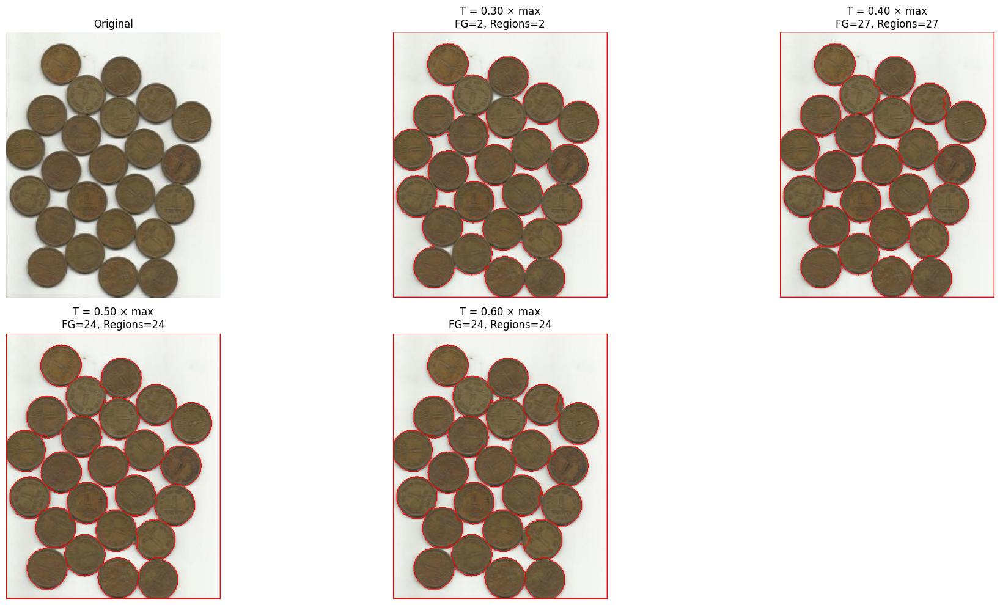

In [78]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

for i, exp in enumerate(experiments, start=2):

    result_rgb = cv2.cvtColor(
        exp["result"],
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i)

    plt.imshow(result_rgb)

    plt.title(
        f"T = {exp['factor']:.2f} × max\n"
        f"FG={exp['foreground_markers']}, "
        f"Regions={exp['separated_regions']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [79]:
print(
    f"{'Experiment':<12}"
    f"{'Distance Threshold':<20}"
    f"{'Foreground':<15}"
    f"{'Regions':<12}"
    f"{'Observed Result'}"
)

print("-" * 85)

for i, exp in enumerate(experiments, start=1):

    print(
        f"{i:<12}"
        f"{exp['factor']:.2f} × max{'':<10}"
        f"{exp['foreground_markers']:<15}"
        f"{exp['separated_regions']:<12}"
        f"{'Inspect visually'}"
    )

Experiment  Distance Threshold  Foreground     Regions     Observed Result
-------------------------------------------------------------------------------------
1           0.30 × max          2              2           Inspect visually
2           0.40 × max          27             27          Inspect visually
3           0.50 × max          24             24          Inspect visually
4           0.60 × max          24             24          Inspect visually


In [80]:
for i, exp in enumerate(experiments, start=1):

    filename = (
        f"task8_experiment_{i}_"
        f"threshold_{exp['factor']:.2f}.png"
    )

    cv2.imwrite(
        f"output/{filename}",
        exp["result"]
    )


Increasing the distance-transform threshold reduced the size of the sure-foreground regions. At lower thresholds, foreground regions belonging to touching coins remained connected, resulting in too few markers and merged watershed regions. At moderate thresholds, the foreground regions became sufficiently separated so that individual coins received distinct markers, producing more meaningful watershed boundaries. At excessively high thresholds, the sure-foreground regions became very small, and some objects risked losing reliable markers. Therefore, an intermediate distance-transform threshold provided the best balance between separating touching objects and preserving a valid marker for each coin.

## Task 9

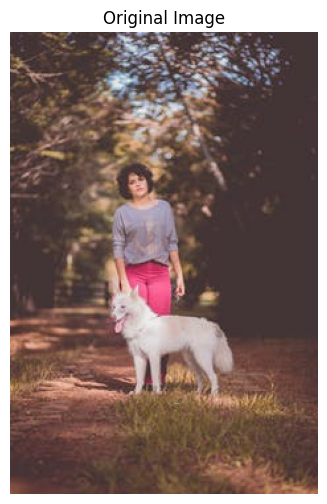

In [83]:
image = cv2.imread("input/dog.jpeg")

if image is None:
    raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [84]:
pixels = image_rgb.reshape((-1, 3))

print("Original image shape:", image_rgb.shape)
print("Reshaped pixel data:", pixels.shape)

Original image shape: (350, 233, 3)
Reshaped pixel data: (81550, 3)


In [85]:
pixel_values = np.float32(pixels)

print("Data type:", pixel_values.dtype)

Data type: float32


In [86]:
def kmeans_segment(image_rgb, K):
  pixel_values = image_rgb.reshape((-1, 3))
  pixel_values = np.float32(pixel_values)

  criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

  compactness, labels, centers = cv2.kmeans(pixel_values,K,None,criteria,10, cv2.KMEANS_RANDOM_CENTERS)

  centers = np.uint8(centers)

  segmented_pixels = centers[labels.flatten()]

  segmented_image = segmented_pixels.reshape(image_rgb.shape)

  return segmented_image, centers, labels, compactness

k=2

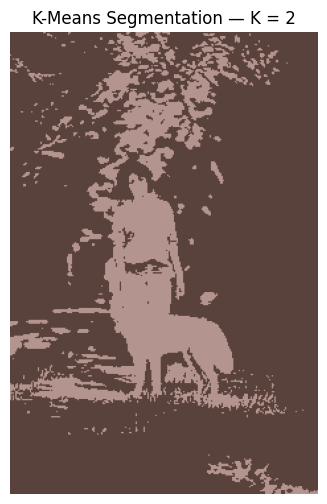

In [87]:
segmented_k2, centers_k2, labels_k2, compactness_k2 = kmeans_segment(image_rgb,2)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_k2)
plt.title("K-Means Segmentation — K = 2")
plt.axis("off")
plt.show()

k=4

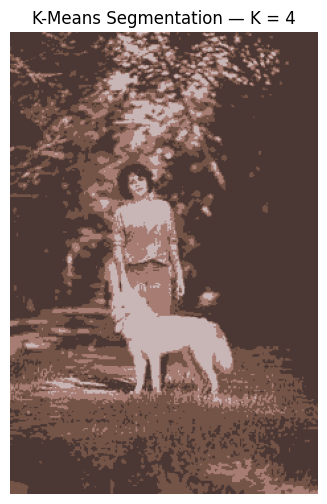

In [88]:
segmented_k4, centers_k4, labels_k4, compactness_k4 = kmeans_segment(image_rgb,4)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_k4)
plt.title("K-Means Segmentation — K = 4")
plt.axis("off")
plt.show()

k=6

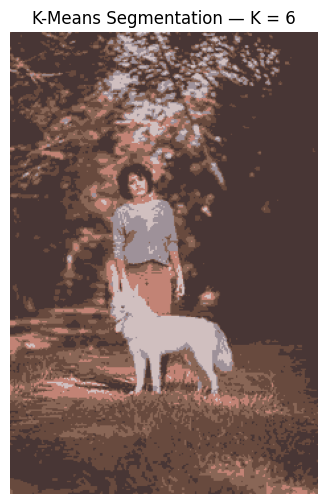

In [89]:
segmented_k6, centers_k6, labels_k6, compactness_k6 = kmeans_segment(image_rgb,6)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_k6)
plt.title("K-Means Segmentation — K = 6")
plt.axis("off")
plt.show()

compare

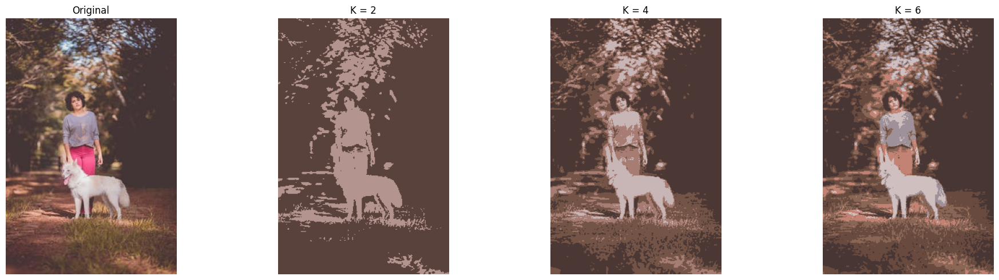

In [90]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(segmented_k2)
plt.title("K = 2")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(segmented_k4)
plt.title("K = 4")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(segmented_k6)
plt.title("K = 6")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task9.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
print("Cluster centers for K = 2:")
print(centers_k2)

print("\nCluster centers for K = 4:")
print(centers_k4)

print("\nCluster centers for K = 6:")
print(centers_k6)

Cluster centers for K = 2:
[[180 148 142]
 [ 90  66  60]]

Cluster centers for K = 4:
[[166 124 115]
 [ 75  56  53]
 [200 181 182]
 [116  84  70]]

Cluster centers for K = 6:
[[158 145 153]
 [137 102  86]
 [104  74  62]
 [208 191 191]
 [194 131 117]
 [ 72  54  53]]


Color simplification decreases as K increases. K = 2 provides the strongest simplification because all pixels are represented using only two colors. K = 4 preserves additional color groups, while K = 6 retains the greatest amount of color variation among the tested settings.

## Task 10

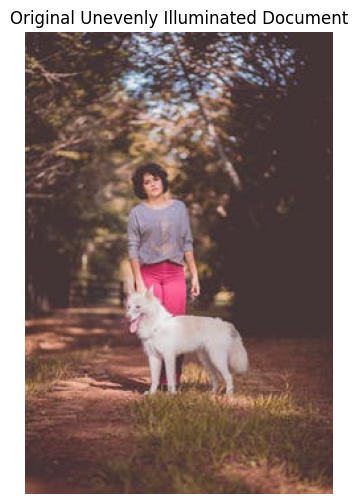

In [93]:
image = cv2.imread("input/dog.jpeg")

if image is None:
    raise FileNotFoundError("Image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Unevenly Illuminated Document")
plt.axis("off")
plt.show()

gloabal thresholding

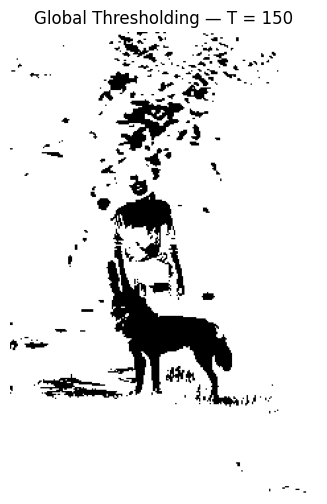

In [94]:
global_threshold = 150

_, global_mask = cv2.threshold(gray,global_threshold,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(8, 6))
plt.imshow(global_mask, cmap="gray")
plt.title(f"Global Thresholding — T = {global_threshold}")
plt.axis("off")
plt.show()

Global thresholding assumes that one threshold value can separate text from background across the entire image. It successfully identifies text in uniformly illuminated regions but may miss faint characters or incorrectly classify dark/shadowed background regions as text. The threshold value \(T\) has the greatest effect on the result; a low value may remove valid text, while a high value may introduce background noise

otsu thresholding

Automatically selected Otsu threshold: 113.0


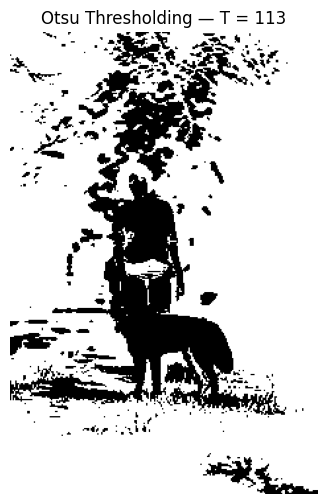

In [95]:
otsu_threshold, otsu_mask = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print("Automatically selected Otsu threshold:", otsu_threshold)

plt.figure(figsize=(8, 6))
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Otsu Thresholding — T = {otsu_threshold:.0f}")
plt.axis("off")
plt.show()

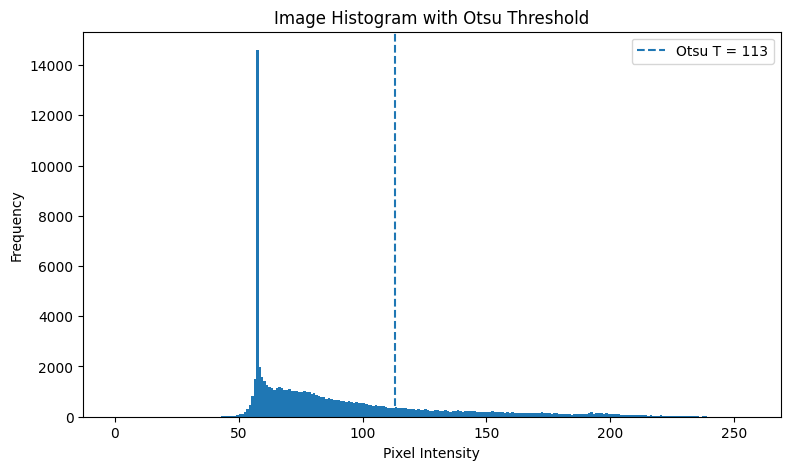

In [96]:
plt.figure(figsize=(9, 5))

plt.hist(gray.ravel(),bins=256,range=[0, 256])

plt.axvline(otsu_threshold,linestyle="--",label=f"Otsu T = {otsu_threshold:.0f}")

plt.title("Image Histogram with Otsu Threshold")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Otsu’s thresholding assumes that the grayscale intensity distribution can be separated into foreground and background classes using a single automatically selected threshold. It successfully extracts text where the intensity groups are clearly separated, but it can still fail in regions with strong illumination variation because the same threshold is applied to the whole image. Its result is mainly affected by the image intensity distribution and preprocessing.

Adaptive gaussian thresholding

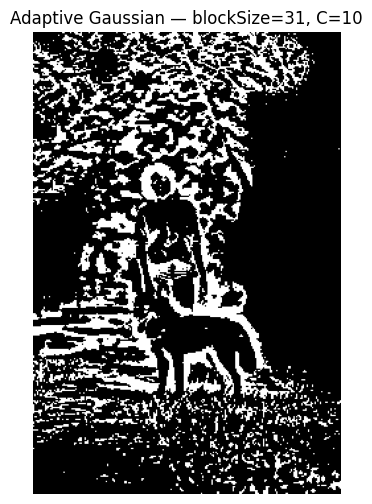

In [97]:
block_size = 31
C = 10

adaptive_mask = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,block_size,C)

plt.figure(figsize=(8, 6))
plt.imshow(adaptive_mask, cmap="gray")
plt.title(f"Adaptive Gaussian — blockSize={block_size}, C={C}")
plt.axis("off")
plt.show()

Adaptive Gaussian thresholding assumes that text and background can be distinguished using local intensity information rather than one global threshold. It successfully preserves text across both bright and dark regions of the document and handles uneven illumination better. Incorrect segmentation may occur as local noise or broken characters if the parameters are poorly selected. The blockSize has the greatest effect on the local neighbourhood used for threshold calculation, while C controls how restrictive the segmentation is.

inspect foreground percentages

In [98]:
def foreground_percentage(mask):
    return np.count_nonzero(mask) / mask.size * 100


print(
    f"Global foreground:   "
    f"{foreground_percentage(global_mask):.2f}%"
)

print(
    f"Otsu foreground:     "
    f"{foreground_percentage(otsu_mask):.2f}%"
)

print(
    f"Adaptive foreground: "
    f"{foreground_percentage(adaptive_mask):.2f}%"
)

Global foreground:   89.08%
Otsu foreground:     77.59%
Adaptive foreground: 22.45%


comparison

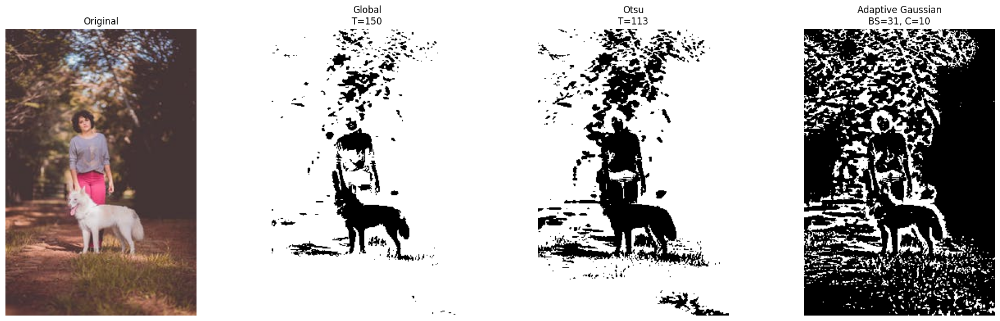

In [99]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(global_mask, cmap="gray")
plt.title(f"Global\nT={global_threshold}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Otsu\nT={otsu_threshold:.0f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(adaptive_mask, cmap="gray")
plt.title(f"Adaptive Gaussian\n"f"BS={block_size}, C={C}")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "output/task10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The three segmentation methods produced noticeably different results on the unevenly illuminated document. Global thresholding successfully extracted text in regions where foreground and background intensities were clearly separated, but a single manually selected threshold could not handle the full illumination range. Otsu's method automatically selected a global threshold and removed the need for manual threshold selection, but it still exhibited errors in regions affected by strong illumination changes because one threshold was applied to the complete image. Adaptive Gaussian thresholding produced the most meaningful text regions in this experiment because its threshold was calculated from local neighbourhoods, allowing it to respond to brightness variation across the document. Its suitability therefore comes from the spatially varying illumination present in this particular image rather than from adaptive thresholding being universally superior.